In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mehakwadhwa30","key":"c4d26aa8a5ecc4325a7ba32af185c86d"}'}

In [2]:
import os
import shutil

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')

os.chmod('/root/.kaggle/kaggle.json', 600)

print("Kaggle setup done ✅")

Kaggle setup done ✅


In [3]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:23<00:00, 15.3MB/s]



In [4]:
import zipfile

zip_path = "intel-image-classification.zip"
extract_path = "/content/intel_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done ✅")

Extraction done ✅


In [5]:
import os

base_path = "/content/intel_data"

for root, dirs, files in os.walk(base_path):
    print("Current Path:", root)
    print("Folders:", dirs)
    print("-----")
    break

Current Path: /content/intel_data
Folders: ['seg_train', 'seg_test', 'seg_pred']
-----


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 150
BATCH_SIZE = 32

train_dir = "/content/intel_data/seg_train/seg_train"
test_dir = "/content/intel_data/seg_test/seg_test"

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [11]:
from tensorflow import keras
from tensorflow.keras import layers

model_basic = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

model_basic.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history_basic = model_basic.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.6209 - loss: 1.3309 - val_accuracy: 0.6707 - val_loss: 0.8976
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.8054 - loss: 0.5639 - val_accuracy: 0.7343 - val_loss: 0.7610
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.8987 - loss: 0.3137 - val_accuracy: 0.7523 - val_loss: 0.7795
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9455 - loss: 0.1780 - val_accuracy: 0.7187 - val_loss: 1.0453
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.9758 - loss: 0.0908 - val_accuracy: 0.7440 - val_loss: 0.9951


In [13]:
loss_basic, acc_basic = model_basic.evaluate(test_data)
print("Basic CNN Accuracy:", acc_basic)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7440 - loss: 0.9951
Basic CNN Accuracy: 0.7440000176429749


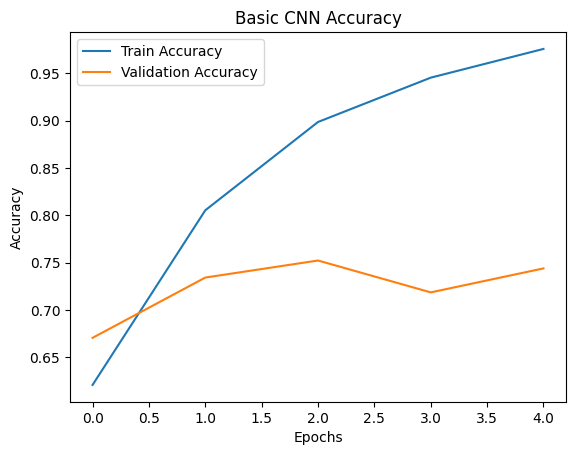

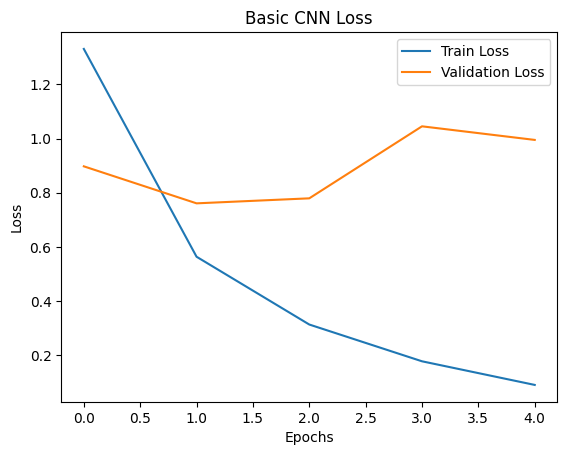

In [22]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.plot(history_basic.history['accuracy'], label='Train Accuracy')
plt.plot(history_basic.history['val_accuracy'], label='Validation Accuracy')
plt.title('Basic CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Graph
plt.plot(history_basic.history['loss'], label='Train Loss')
plt.plot(history_basic.history['val_loss'], label='Validation Loss')
plt.title('Basic CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [7]:
from tensorflow import keras
from tensorflow.keras import layers

NUM_CLASSES = 6

model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(150,150,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 63s 103ms/step - accuracy: 0.6720 - loss: 0.9627 - val_accuracy: 0.3227 - val_loss: 2.9841
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 32s 73ms/step - accuracy: 0.7855 - loss: 0.6045 - val_accuracy: 0.7617 - val_loss: 0.6686
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 32s 74ms/step - accuracy: 0.8176 - loss: 0.5105 - val_accuracy: 0.8120 - val_loss: 0.5248
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 33s 74ms/step - accuracy: 0.8258 - loss: 0.4791 - val_accuracy: 0.6900 - val_loss: 0.9603
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 35s 80ms/step - accuracy: 0.8534 - loss: 0.4063 - val_accuracy: 0.8157 - val_loss: 0.5375


In [10]:
test_loss, test_acc = model.evaluate(test_data)
print("Advanced CNN Accuracy:", test_acc)


94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8157 - loss: 0.5375
Test Accuracy: 0.815666675567627


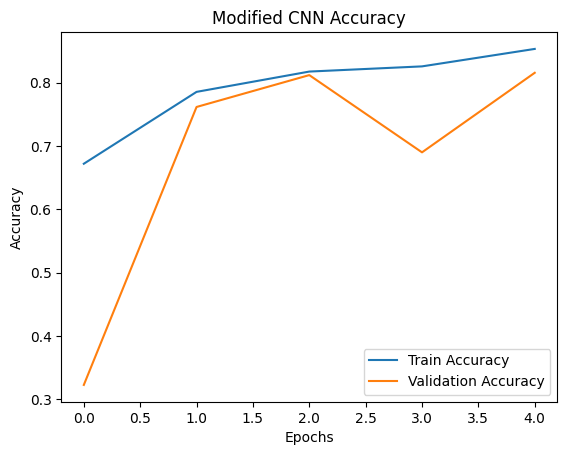

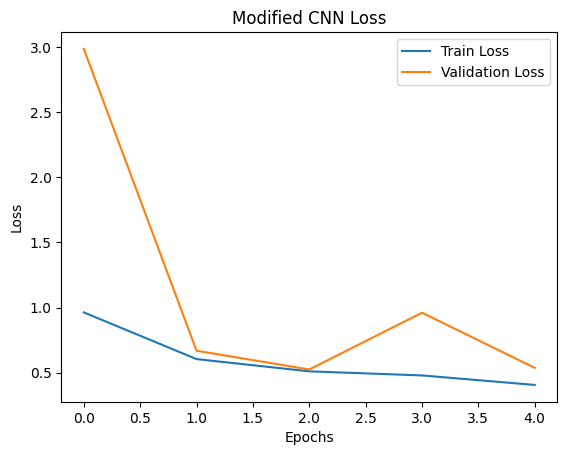

In [23]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Modified CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Modified CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8,1.2]
)

train_data_aug = train_datagen_aug.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

Found 14034 images belonging to 6 classes.


In [19]:
history_aug = model.fit(
    train_data_aug,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 109s 249ms/step - accuracy: 0.8367 - loss: 0.4584 - val_accuracy: 0.8477 - val_loss: 0.4595
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 111s 253ms/step - accuracy: 0.8477 - loss: 0.4290 - val_accuracy: 0.8653 - val_loss: 0.4195
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 109s 248ms/step - accuracy: 0.8558 - loss: 0.4053 - val_accuracy: 0.8323 - val_loss: 0.5342
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 109s 248ms/step - accuracy: 0.8583 - loss: 0.3910 - val_accuracy: 0.8557 - val_loss: 0.4431
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 108s 246ms/step - accuracy: 0.8607 - loss: 0.3872 - val_accuracy: 0.7997 - val_loss: 0.5645


In [20]:
loss_aug, acc_aug = model.evaluate(test_data)
print("Augmented Model Accuracy:", acc_aug)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7997 - loss: 0.5645
Augmented Model Accuracy: 0.7996666431427002


In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=2, restore_best_weights=True)

history_reg = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 34s 78ms/step - accuracy: 0.8992 - loss: 0.2872 - val_accuracy: 0.8760 - val_loss: 0.3626
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 33s 76ms/step - accuracy: 0.9196 - loss: 0.2268 - val_accuracy: 0.8783 - val_loss: 0.3582
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 33s 75ms/step - accuracy: 0.9326 - loss: 0.1915 - val_accuracy: 0.8127 - val_loss: 0.5393
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 33s 76ms/step - accuracy: 0.9417 - loss: 0.1596 - val_accuracy: 0.8900 - val_loss: 0.3544
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 33s 74ms/step - accuracy: 0.9572 - loss: 0.1190 - val_accuracy: 0.8510 - val_loss: 0.4742
